In [1]:
!pip install pillow
!pip install tensorflow

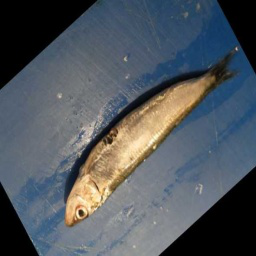

In [2]:
from PIL import Image

im = Image.open("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train/fish sea_food black_sea_sprat/0A4HBJ5YPTT5.jpg")
im

In [3]:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Rotate images by up to 20 degrees
    width_shift_range=0.2,  # Shift images horizontally by up to 20% of width
    height_shift_range=0.2, # Shift images vertically by up to 20% of height
    shear_range=0.2,  # Apply shear transformation
    zoom_range=0.2,  # Zoom in/out by up to 20%
    horizontal_flip=True, # Randomly flip images horizontally
    fill_mode='nearest' # Fill newly created pixels with the nearest value
)

In [4]:
val_test_gen = ImageDataGenerator(rescale=1./255)

In [5]:
img_h = 224
img_w = 224
batch_size = 32

In [6]:
train_ds = train_datagen.flow_from_directory("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train",
                                         target_size=(img_h, img_w),
                                         batch_size=batch_size,
                                         class_mode='categorical')

val_ds = val_test_gen.flow_from_directory("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val",
                                          target_size=(img_h, img_w),
                                          batch_size=batch_size,
                                          class_mode='categorical')

test_ds = val_test_gen.flow_from_directory("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test",
                                           target_size=(img_h, img_w),
                                           batch_size=batch_size,
                                           class_mode='categorical',
                                           shuffle=False)    # For correct label matching during evaluation

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


In [7]:
train_ds

In [8]:
classes = list(train_ds.class_indices)
classes

['animal fish',
 'animal fish bass',
 'fish sea_food black_sea_sprat',
 'fish sea_food gilt_head_bream',
 'fish sea_food hourse_mackerel',
 'fish sea_food red_mullet',
 'fish sea_food red_sea_bream',
 'fish sea_food sea_bass',
 'fish sea_food shrimp',
 'fish sea_food striped_red_mullet',
 'fish sea_food trout']

In [9]:
test_ds.num_classes

11

In [10]:
val_ds.filepaths[:5]

['E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val\\animal fish\\00INXORZNTLJ.jpg',
 'E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val\\animal fish\\037HBUROQJPG.jpg',
 'E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val\\animal fish\\04H7O05DX3CU.jpg',
 'E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val\\animal fish\\09K1Q2K4PL5O.jpg',
 'E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val\\animal fish\\0BL5YTSEHIRZ.jpg']

In [11]:
images, labels = next(train_ds) # Get single batch of train dataset
print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 11)


In [12]:
val_ds.num_batches

35

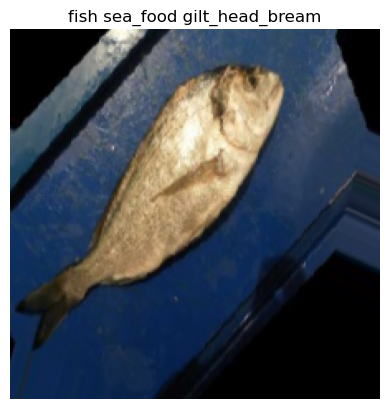

In [13]:
import matplotlib.pyplot as plt
plt.imshow(images[7])
plt.title(classes[labels[7].argmax()])
plt.axis("off")
plt.show()

In [14]:
type(train_ds)

keras.src.legacy.preprocessing.image.DirectoryIterator

In [15]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_h, img_w, 3)),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_ds.num_classes, activation='softmax')])

In [16]:
cnn_model.compile(optimizer='adam',
                  loss="categorical_crossentropy",
                  metrics=['accuracy'])


In [17]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,851 (49.36 MB)

 Trainable params: 12,939,851 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn = cnn_model.fit(train_ds,
                            validation_data=val_ds,
                            epochs=30,
                           )

Epoch 1/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 133s 677ms/step - accuracy: 0.3304 - loss: 1.8842 - val_accuracy: 0.5385 - val_loss: 1.4891
Epoch 2/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 134s 686ms/step - accuracy: 0.5027 - loss: 1.3572 - val_accuracy: 0.7051 - val_loss: 0.9471
Epoch 3/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 132s 678ms/step - accuracy: 0.5868 - loss: 1.1211 - val_accuracy: 0.7198 - val_loss: 0.7644
Epoch 4/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 133s 682ms/step - accuracy: 0.6484 - loss: 0.9830 - val_accuracy: 0.7244 - val_loss: 0.6985
Epoch 5/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 136s 697ms/step - accuracy: 0.6908 - loss: 0.8730 - val_accuracy: 0.8526 - val_loss: 0.4671
Epoch 6/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 133s 680ms/step - accuracy: 0.7340 - loss: 0.7628 - val_accuracy: 0.8507 - val_loss: 0.4563
Epoch 7/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 133s 682ms/step - accuracy: 0.7438 - loss: 0.7202 - val_accuracy: 0.7821 - val_loss: 0.5768
Epoch 8/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 132s 678ms/step - accuracy: 0.7611 -

In [19]:
train_accuracy = cnn.history['accuracy']
train_loss = cnn.history['loss']

val_accuracy = cnn.history['val_accuracy']
val_loss = cnn.history['val_loss']

epochs = range(1, len(train_accuracy)+1)

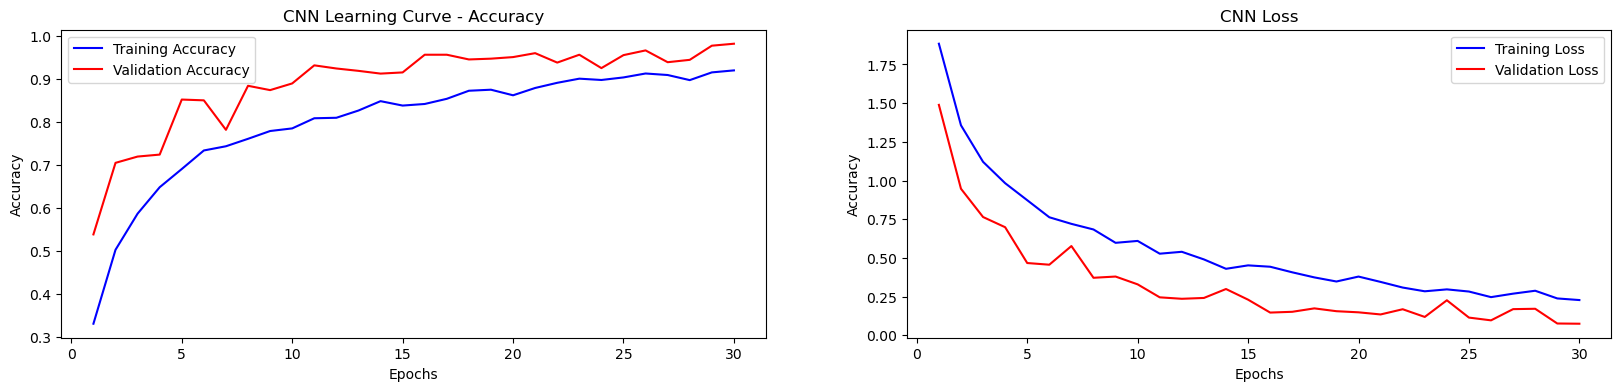

In [20]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Learning Curve - Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Loss")

plt.show()

In [21]:
cnn_model.save("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Trained Models/multiclass_fish_cnn_model.h5")

In [22]:
cnn_model.save("E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Trained Models/multiclass_fish_cnn_model.keras")

In [23]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_ds)
cnn_accuracy

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.9834 - loss: 0.0700


0.9833699464797974

In [26]:

import numpy as np
y_probs = cnn_model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)
y_pred.shape
y_true = test_ds.classes
y_true.shape
y_true_labels = [classes[labels] for labels in y_true]
y_pred_labels = [classes[labels] for labels in y_pred]

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step


In [28]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix

cnn_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
cnn_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
cnn_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
cnn_cm = confusion_matrix(y_true_labels, y_pred_labels)

In [29]:
print("CNN Model Performance Metrics:\n")
print(f" Accuracy : {cnn_accuracy*100:.4f}%")
print(f" Loss     : {cnn_loss:.4f}")
print(f" Precision: {cnn_precision:.4f}")
print(f" Recall   : {cnn_recall:.4f}")
print(f" F1 Score : {cnn_f1:.4f}")

CNN Model Performance Metrics:

 Accuracy : 98.3370%
 Loss     : 0.0700
 Precision: 0.9797
 Recall   : 0.9834
 F1 Score : 0.9812


In [30]:
print(test_ds.class_indices)

{'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}


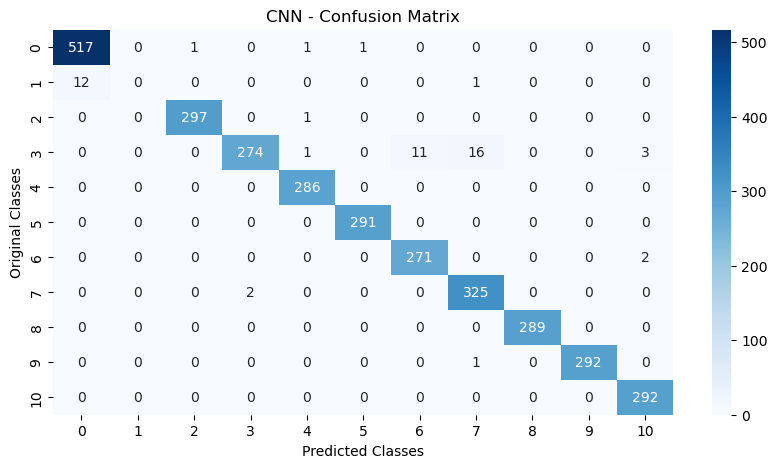

In [31]:
plt.figure(figsize=(10,5))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Classes")
plt.ylabel("Original Classes")
plt.title("CNN - Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix, classification_report
cnn_cr = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
print(cnn_cr)

                                  precision    recall  f1-score   support

                     animal fish       0.98      0.99      0.99       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       0.99      0.90      0.94       305
   fish sea_food hourse_mackerel       0.99      1.00      0.99       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       0.96      0.99      0.98       273
          fish sea_food sea_bass       0.95      0.99      0.97       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
             fish sea_food trout       0.98      1.00      0.99       292

                        accuracy                           0.98      3187
                       macro avg    

In [33]:
pretrained_models = {
    "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "MobileNet": MobileNet(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "InceptionV3": InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "EfficientNetB0": EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
}

In [34]:
# Function to load and modify a pre-trained model
def load_pretrained_model(base_model, input_shape, num_classes):

  base_model.trainable = False

  model = Sequential([
          base_model,
          GlobalAveragePooling2D(),
          Dense(128, activation='relu'),
          Dropout(0.5),
          Dense(num_classes, activation='softmax')
      ])
  model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [35]:
# Train and evaluate each pretrained model
best_model = None
best_accuracy = 0.0
BEST_MODEL_PATH = "E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Trained Models/multiclass_fish_cnn_model.keras"
history_dict = {}
metrics_dict = {}

for model_name, base_model in pretrained_models.items():
    print(f"\nTraining {model_name} model...\n")
    model = load_pretrained_model(base_model, (224, 224, 3), num_classes=11)
    checkpoint = ModelCheckpoint(BEST_MODEL_PATH, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=[checkpoint, early_stopping])

    history_dict[model_name] = history.history

    val_preds = np.argmax(model.predict(val_ds), axis=1)
    val_labels = val_ds.classes

    accuracy = accuracy_score(val_labels, val_preds)
    metrics_dict[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision_score(val_labels, val_preds, average='macro', zero_division=1),
        "Recall": recall_score(val_labels, val_preds, average='macro'),
        "F1 Score": f1_score(val_labels, val_preds, average='macro'),
        "Confusion Matrix": confusion_matrix(val_labels, val_preds)
    }
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        name = model_name

# Save the Best Model
if best_model:
    best_model.save(BEST_MODEL_PATH)
    joblib.dump(metrics_dict, "model_metrics.pkl")


print(f"Best model {name} saved with accuracy: {best_accuracy}")


Training VGG16 model...

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2980 - loss: 2.0333
Epoch 1: val_accuracy improved from None to 0.67399, saving model to E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Trained Models/multiclass_fish_cnn_model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.3963 - loss: 1.7876 - val_accuracy: 0.6740 - val_loss: 1.3449
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5847 - loss: 1.3161
Epoch 2: val_accuracy improved from 0.67399 to 0.80220, saving model to E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Trained Models/multiclass_fish_cnn_model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.6095 - loss: 1.2462 - val_accuracy: 0.8022 - val_loss: 0.8964
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6882 - loss: 1.0075
Epoch 3: val_accuracy improved from 0.80220 to 0.82143, saving model to E:/Project5/Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/Train

In [36]:
metrics_dict = joblib.load("model_metrics.pkl")
dic = pd.DataFrame.from_dict({model: {k: v for k, v in metrics_dict[model].items() if k != "Confusion Matrix"} for model in metrics_dict}, orient='index')
dic

,Accuracy,Precision,Recall,F1 Score
VGG16,0.117216,0.188720,0.098166,0.097823
ResNet50,0.121795,0.427237,0.093062,0.068084
MobileNet,0.108059,0.094124,0.094288,0.094205
InceptionV3,0.108059,0.095079,0.095214,0.095103
EfficientNetB0,0.171245,0.924659,0.090909,0.026583


<Figure size 300x100 with 0 Axes>

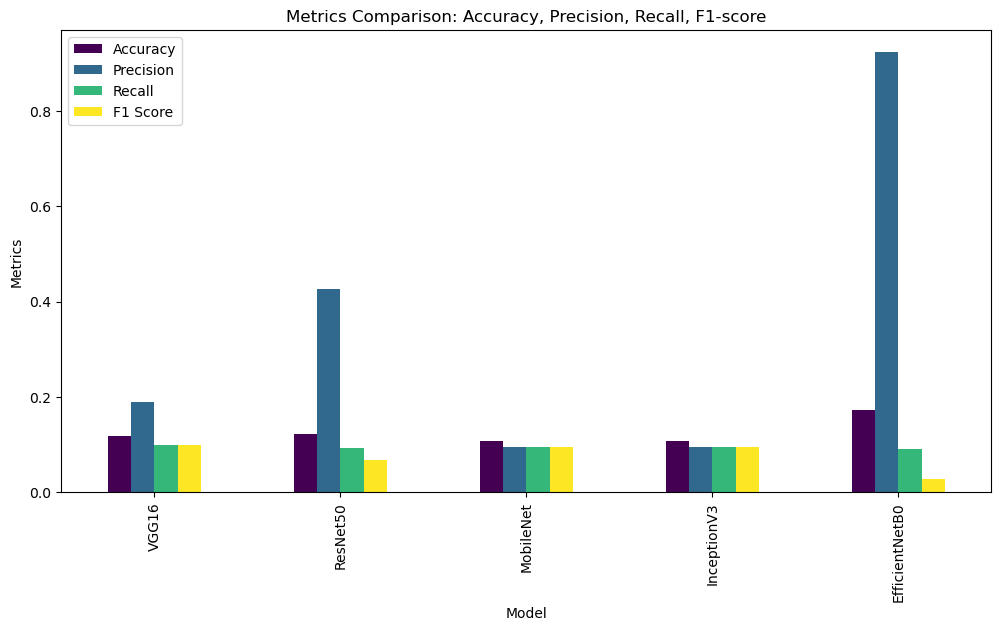

In [37]:
plt.figure(figsize=(3, 1))
dic.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.xlabel("Model")
plt.ylabel("Metrics")
plt.title("Metrics Comparison: Accuracy, Precision, Recall, F1-score")
plt.show()

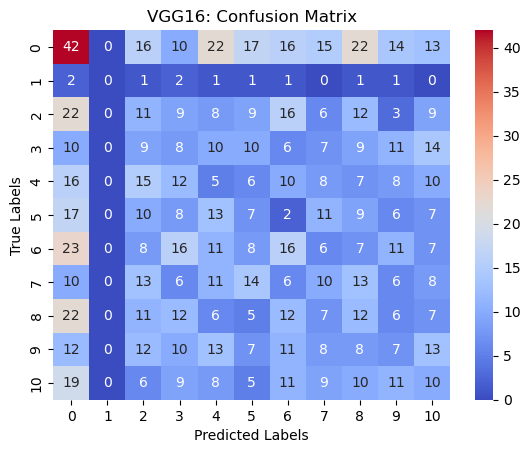

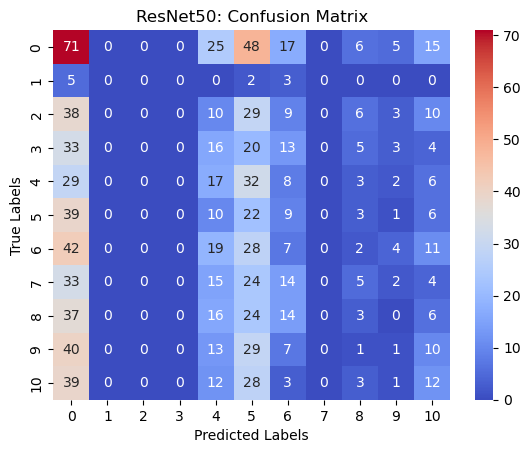

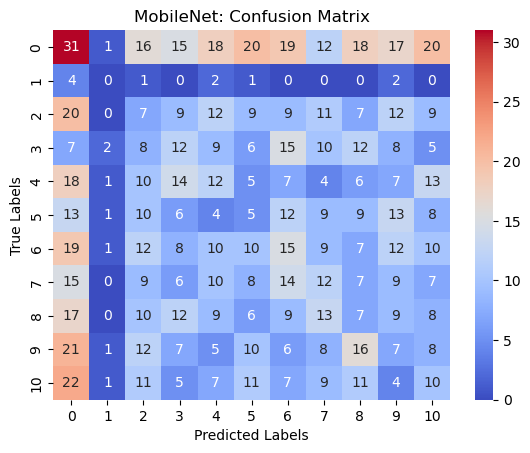

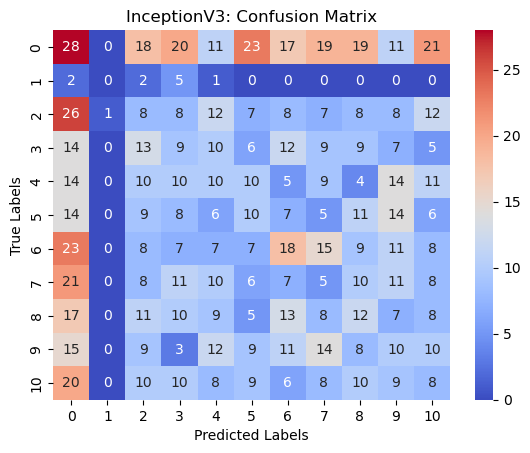

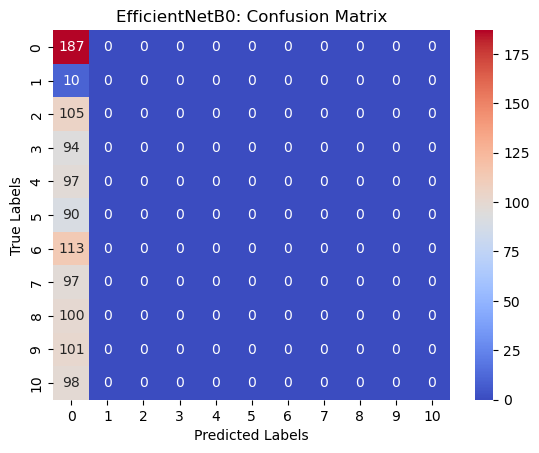

In [38]:
for model_name, metrics in metrics_dict.items():
  cm = metrics["Confusion Matrix"]
  sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
  plt.title(f"{model_name}: Confusion Matrix")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()
